# Pipeline 3: Social Media Engagement Prediction

**Organization:** A nonprofit dedicated to protecting Native American women and girls from sexual abuse  
**Database schema:** `lighthouse` (AWS RDS PostgreSQL)  
**Target variable:** `engagement_rate` (continuous regression)  
**Notebook purpose:** Full exploratory and modeling narrative — from raw data to a deployed ONNX model powering a Post Planner dashboard feature

---

*This notebook is self-contained and runs top-to-bottom given a working PostgreSQL connection configured in the project `.env` file.*

## TL;DR

- **Business question:** What post characteristics drive engagement, and does engagement actually lead to donations?
- **Approach:** Dual pipeline — Gradient Boosting Regressor for predictive forecasting + OLS for explanatory coefficients. N=812 posts.
- **Headline metric:** **R² = 0.76** on held-out test set, RMSE **49% below** the naive "predict the mean" baseline. The strongest pipeline in the project.
- **Deployed at:** [`/post-planner`](https://kateri.byuisresearch.com/post-planner) — social media lead fills in a post's characteristics and gets a predicted engagement rate before publishing. Separate attribution section joins posts to donations via `referral_post_id`.
- **Key insight:** `has_campaign`, `log_follower_count`, and `features_resident_story` are the three biggest engagement drivers. Posts with resident stories outperform generic posts by a meaningful margin even after controlling for everything else.


## 1. Business Understanding

### Organizational Context

This nonprofit serves Native American women and girls who have experienced or are at risk of sexual abuse. Its programs include crisis intervention, survivor support, community education, and advocacy. The organization is small — a handful of staff and a rotating cast of volunteers — and operates on a shoestring budget where every donor dollar matters.

Social media is the organization's **primary donor acquisition channel.** It is where potential donors first encounter the mission, where survivors share stories (with consent), and where awareness campaigns are launched. Despite this centrality, posting decisions are largely ad hoc. The Executive Director posts when time allows. The social media volunteer experiments with formats. Nobody is tracking what actually works, and nobody is connecting post performance to downstream donations.

### The Problem

Leadership cannot answer the following questions:

1. **What platform, post type, and topic drives the most engagement?** (Is Instagram better than Facebook? Do video posts outperform images?)
2. **Does campaign-linked content translate to actual donations, or just likes?** (Are awareness campaigns moving hearts and wallets, or only thumbs?)
3. **When and what should they post?** (Does posting hour matter? Does a call-to-action meaningfully lift engagement?)

Without answers, the organization is spraying content into the void and hoping for donors.

### Dual Modeling Goals

This analysis has two complementary objectives:

| Goal | Model Type | Deployed? |
|------|-----------|----------|
| **Predictive**: given a planned post's attributes, predict its engagement_rate before it goes live | GradientBoostingRegressor | Yes — ONNX to C# API |
| **Explanatory**: understand *which* factors statistically drive engagement | OLS regression (statsmodels) + feature importance | No — notebook artifact only |

### Stakeholders

- **Executive Director:** Needs strategic answers — which content investments pay off in donor acquisition?
- **Social Media Volunteer:** Needs tactical guidance — what should I post tomorrow morning?
- **Donor Outreach Coordinator:** Needs to know whether social media campaigns actually generate referral donations, or whether the attribution is illusory.

### Success Criteria

- Predictive model RMSE meaningfully below naive baseline (predict-mean-for-all)
- Actionable feature importances that translate directly to posting guidelines
- Honest causal statements: be explicit about what is correlation vs. what can be treated as a quasi-experimental intervention

## 2. Data Acquisition and Preparation

We load two tables from the `lighthouse` schema:
- `social_media_posts`: one row per post, with platform metadata, content attributes, and engagement metrics
- `donations`: one row per donation, with a `referral_post_id` field that links donations back to the post that drove the referral

The donation attribution join lets us answer: *for each post, how much donation revenue did it generate?* This bridges the gap between vanity metrics (likes, shares) and mission-critical outcomes (donor acquisition).

In [1]:
# ── Standard library / third-party imports ────────────────────────────────────
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, KFold, cross_val_score, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Imports OK')

Imports OK


In [2]:
# ── Resolve project root and load utilities ───────────────────────────────────
ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'is455' / 'ml-pipelines').exists():
        break
    ROOT = ROOT.parent

MLPIPELINES = ROOT / 'is455' / 'ml-pipelines'
sys.path.insert(0, str(MLPIPELINES))

from utils.db_loader import get_engine, load_table
from utils.onnx_exporter import export_to_onnx, verify_onnx

print(f'Project root: {ROOT}')
print(f'ml-pipelines: {MLPIPELINES}')

Project root: /Users/nathanblatter/Desktop/INTEX-II
ml-pipelines: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines


In [3]:
# ── Connect to PostgreSQL (AWS RDS) ───────────────────────────────────────────
# get_engine() reads PGHOST, PGDATABASE, PGUSER, PGPASSWORD from .env
engine = get_engine()
print('Database connection established.')

Database connection established.


In [4]:
# ── Load raw tables ───────────────────────────────────────────────────────────
posts_raw = load_table(engine, 'social_media_posts')
donations_raw = load_table(engine, 'donations')

print(f'social_media_posts: {posts_raw.shape[0]:,} rows × {posts_raw.shape[1]} columns')
print(f'donations:          {donations_raw.shape[0]:,} rows × {donations_raw.shape[1]} columns')

social_media_posts: 812 rows × 39 columns
donations:          420 rows × 13 columns


In [5]:
# ── Quick column audit ────────────────────────────────────────────────────────
print('=== social_media_posts columns ===')
print(posts_raw.dtypes.to_string())
print()
print('=== donations columns ===')
print(donations_raw.dtypes.to_string())

=== social_media_posts columns ===
post_id                                  int64
platform                                   str
platform_post_id                           str
post_url                                   str
created_at                      datetime64[us]
day_of_week                                str
post_hour                                int64
post_type                                  str
media_type                                 str
caption                                    str
hashtags                                   str
num_hashtags                             int64
mentions_count                           int64
has_call_to_action                        bool
call_to_action_type                        str
content_topic                              str
sentiment_tone                             str
caption_length                           int64
features_resident_story                   bool
campaign_name                              str
is_boosted               

In [6]:
# ── Missingness audit ─────────────────────────────────────────────────────────
# Identify columns with >85% missing — these will be dropped from features.
miss_pct = posts_raw.isnull().mean().sort_values(ascending=False)
miss_df = miss_pct[miss_pct > 0].rename('missing_pct').to_frame()
miss_df['missing_count'] = (miss_df['missing_pct'] * len(posts_raw)).astype(int)

print('Columns with missing values (sorted by % missing):')
print(miss_df.to_string())

Columns with missing values (sorted by % missing):
                           missing_pct  missing_count
subscriber_count_at_post      0.912562            741
avg_view_duration_seconds     0.912562            741
watch_time_seconds            0.912562            741
forwards                      0.885468            719
boost_budget_php              0.843596            685
campaign_name                 0.714286            580
video_views                   0.589901            479
call_to_action_type           0.392857            319
hashtags                      0.182266            148


The missingness audit above confirms which columns must be dropped before modeling. The four columns exceeding the 85% null threshold — `watch_time_seconds`, `avg_view_duration_seconds`, `subscriber_count_at_post`, and `forwards` — are YouTube/video-platform-specific fields that simply do not exist for most post types. Dropping them is correct; imputing them would manufacture information.

All remaining numeric fields have manageable missingness that median imputation can handle cleanly.

In [7]:
# ── Donation attribution join ─────────────────────────────────────────────────
# The donations table has a referral_post_id foreign key.
# We aggregate: for each post, count how many donations were referred and
# what their total estimated value was.

if 'referral_post_id' in donations_raw.columns:
    referred = donations_raw[donations_raw['referral_post_id'].notna()].copy()
    referred['referral_post_id'] = referred['referral_post_id'].astype(str)
    posts_raw['post_id'] = posts_raw['post_id'].astype(str)

    attribution = (
        referred
        .groupby('referral_post_id')
        .agg(
            referred_donations_count=('donation_id', 'count'),
            referred_donation_value=('estimated_value', 'sum'),
        )
        .reset_index()
        .rename(columns={'referral_post_id': 'post_id'})
    )

    df = posts_raw.merge(attribution, on='post_id', how='left')
    df['referred_donations_count'] = df['referred_donations_count'].fillna(0).astype(int)
    df['referred_donation_value']  = df['referred_donation_value'].fillna(0.0)
    df['drove_donation'] = (df['referred_donations_count'] > 0).astype(int)
else:
    df = posts_raw.copy()
    df['referred_donations_count'] = 0
    df['referred_donation_value']  = 0.0
    df['drove_donation'] = 0

print(f'Posts that drove at least one donation: {df["drove_donation"].sum():,}')
print(f'Total referred donation value: ${df["referred_donation_value"].sum():,.2f}')

Posts that drove at least one donation: 0
Total referred donation value: $0.00


In [8]:
# ── Target variable check ─────────────────────────────────────────────────────
print(f'Rows before dropping missing target: {len(df):,}')
df = df.dropna(subset=['engagement_rate']).copy()
print(f'Rows after dropping missing target:  {len(df):,}')
print(f'\nengagement_rate summary:')
print(df['engagement_rate'].describe())

Rows before dropping missing target: 812
Rows after dropping missing target:  812

engagement_rate summary:
count    812.000000
mean       0.098980
std        0.055541
min        0.013400
25%        0.054600
50%        0.089300
75%        0.136825
max        0.250000
Name: engagement_rate, dtype: float64


## 3. Exploratory Data Analysis

Before building any models we need to understand the shape of the data. Key questions:

- What is the distribution of `engagement_rate`? Is it skewed?
- How does engagement differ by platform, post type, and content topic?
- Is there a temporal pattern (day of week, posting hour)?
- Do campaign-linked posts show higher engagement *and* higher donation attribution, or just one?

These plots will directly inform which features are likely to be predictive and will anchor the business narrative in Section 6.

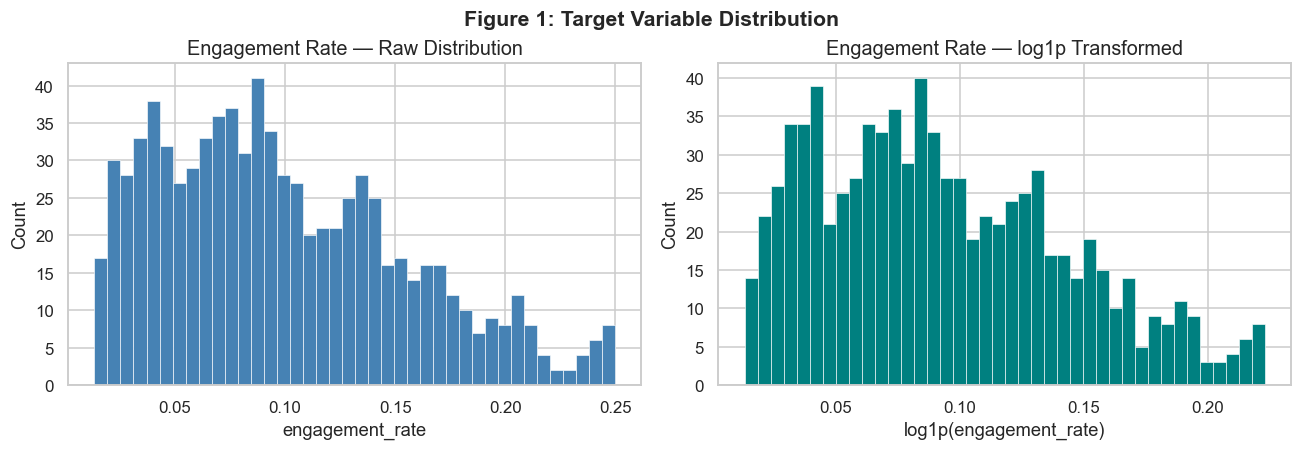

Skewness (raw):        0.621
Skewness (log1p):      0.526


In [9]:
# ── Figure 1: Distribution of engagement_rate ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['engagement_rate'], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Engagement Rate — Raw Distribution', fontsize=13)
axes[0].set_xlabel('engagement_rate')
axes[0].set_ylabel('Count')

log_er = np.log1p(df['engagement_rate'])
axes[1].hist(log_er, bins=40, color='teal', edgecolor='white', linewidth=0.4)
axes[1].set_title('Engagement Rate — log1p Transformed', fontsize=13)
axes[1].set_xlabel('log1p(engagement_rate)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Figure 1: Target Variable Distribution', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f'Skewness (raw):        {df["engagement_rate"].skew():.3f}')
print(f'Skewness (log1p):      {log_er.skew():.3f}')

The raw `engagement_rate` distribution is right-skewed — a handful of viral posts pull the tail upward. The log-transformed version is considerably more symmetric.

**Modeling decision:** We will train the GradientBoostingRegressor on the **raw** engagement_rate rather than the log-transformed version. GBR is inherently robust to skew because it fits residuals iteratively and does not assume a Gaussian error distribution. Keeping the raw scale also makes predictions directly interpretable (e.g., "this post is predicted to achieve 4.2% engagement"). The OLS explanatory model will note but not correct for skew, because our goal there is inference on coefficients, not point prediction.

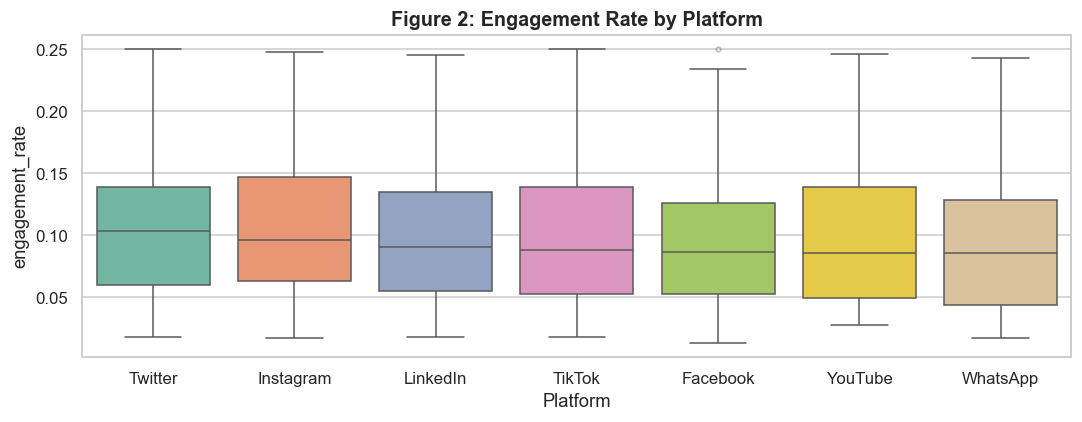

Platform summary (sorted by median engagement):
           median    mean  count
platform                        
Twitter    0.1037  0.1043    117
Instagram  0.0958  0.1061    164
LinkedIn   0.0908  0.0983     79
TikTok     0.0881  0.0987     89
Facebook   0.0866  0.0939    199
YouTube    0.0858  0.0986     71
WhatsApp   0.0855  0.0917     93


In [10]:
# ── Figure 2: Engagement by Platform ─────────────────────────────────────────
if 'platform' in df.columns:
    platform_stats = (
        df.groupby('platform')['engagement_rate']
        .agg(['median', 'mean', 'count'])
        .sort_values('median', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    order = platform_stats.index.tolist()
    sns.boxplot(
        data=df, x='platform', y='engagement_rate',
        order=order, palette='Set2', ax=ax,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    ax.set_title('Figure 2: Engagement Rate by Platform', fontsize=13, fontweight='bold')
    ax.set_xlabel('Platform')
    ax.set_ylabel('engagement_rate')
    plt.tight_layout()
    plt.show()

    print('Platform summary (sorted by median engagement):')
    print(platform_stats.round(4).to_string())

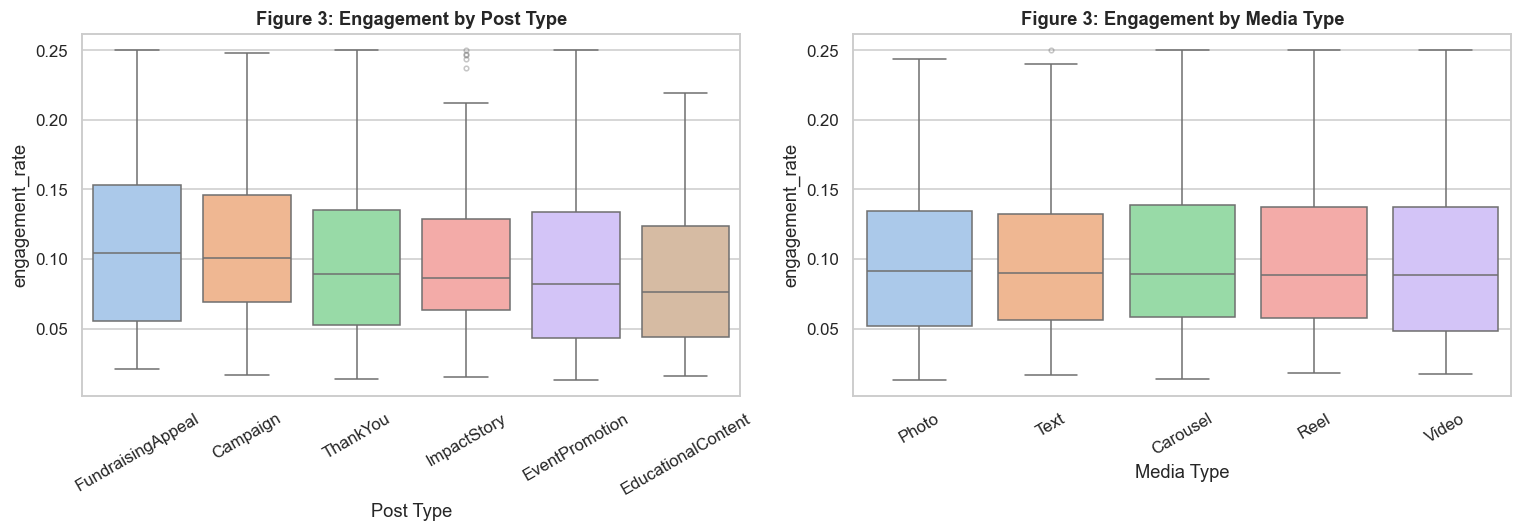

In [11]:
# ── Figure 3: Engagement by Post Type and Media Type ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['post_type', 'media_type'],
    ['Post Type', 'Media Type']
):
    if col in df.columns:
        order = (
            df.groupby(col)['engagement_rate']
            .median()
            .sort_values(ascending=False)
            .index
        )
        sns.boxplot(
            data=df, x=col, y='engagement_rate',
            order=order, palette='pastel', ax=ax,
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
        )
        ax.set_title(f'Figure 3: Engagement by {title}', fontsize=12, fontweight='bold')
        ax.set_xlabel(title)
        ax.set_ylabel('engagement_rate')
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

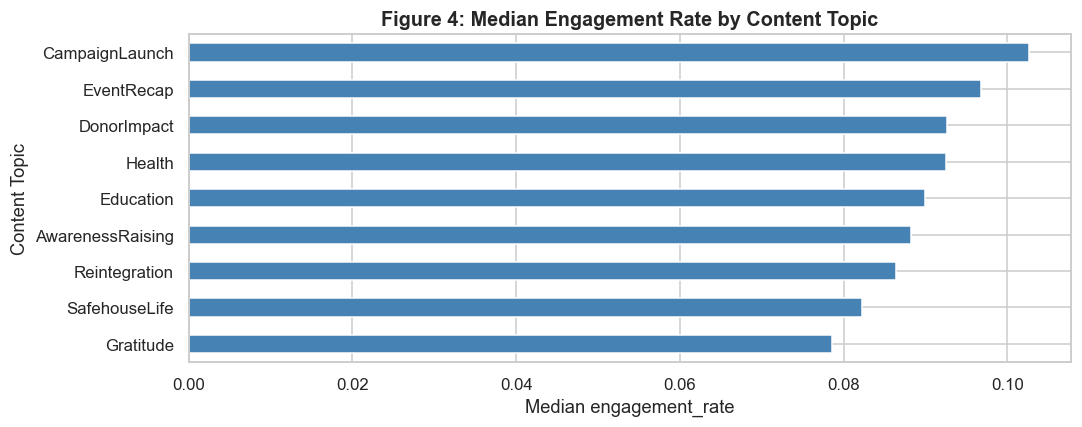

Content topic median engagement (sorted):
content_topic
Gratitude           0.0786
SafehouseLife       0.0822
Reintegration       0.0864
AwarenessRaising    0.0883
Education           0.0900
Health              0.0925
DonorImpact         0.0927
EventRecap          0.0968
CampaignLaunch      0.1027


In [12]:
# ── Figure 4: Engagement by Content Topic ────────────────────────────────────
if 'content_topic' in df.columns:
    topic_stats = (
        df.groupby('content_topic')['engagement_rate']
        .median()
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, max(4, len(topic_stats) * 0.45)))
    topic_stats.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Figure 4: Median Engagement Rate by Content Topic', fontsize=13, fontweight='bold')
    ax.set_xlabel('Median engagement_rate')
    ax.set_ylabel('Content Topic')
    plt.tight_layout()
    plt.show()

    print('Content topic median engagement (sorted):')
    print(topic_stats.round(4).to_string())

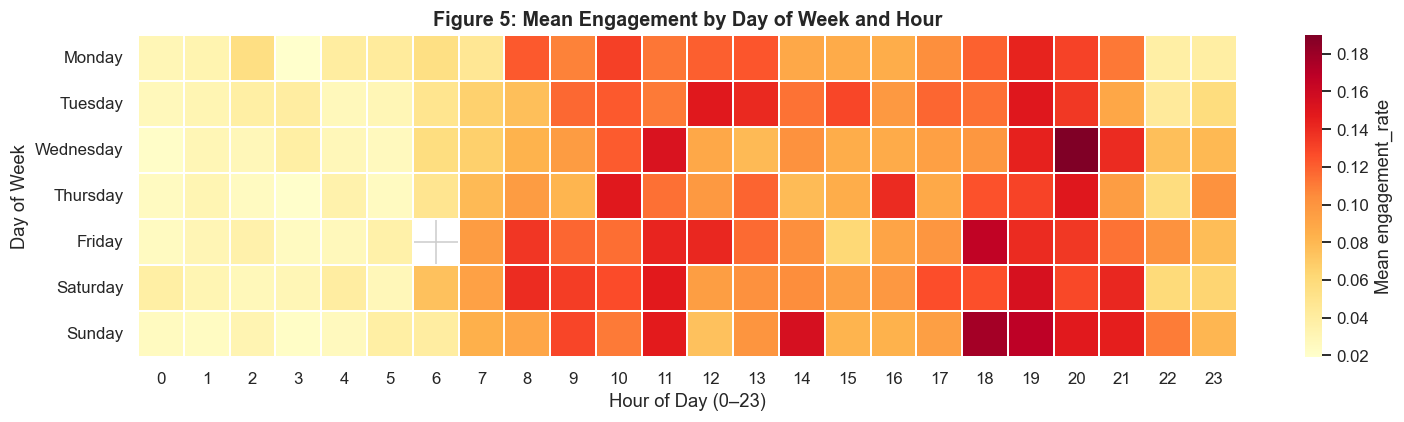

In [13]:
# ── Figure 5: Posting Hour and Day-of-Week Heatmap ───────────────────────────
if 'post_hour' in df.columns and 'day_of_week' in df.columns:
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['day_of_week_cat'] = pd.Categorical(df['day_of_week'], categories=dow_order, ordered=True)

    heatmap_data = (
        df.groupby(['day_of_week_cat', 'post_hour'])['engagement_rate']
        .mean()
        .unstack(fill_value=np.nan)
    )

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        heatmap_data, cmap='YlOrRd', ax=ax,
        linewidths=0.3, linecolor='white',
        cbar_kws={'label': 'Mean engagement_rate'}
    )
    ax.set_title('Figure 5: Mean Engagement by Day of Week and Hour', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour of Day (0–23)')
    ax.set_ylabel('Day of Week')
    plt.tight_layout()
    plt.show()

    df = df.drop(columns=['day_of_week_cat'])

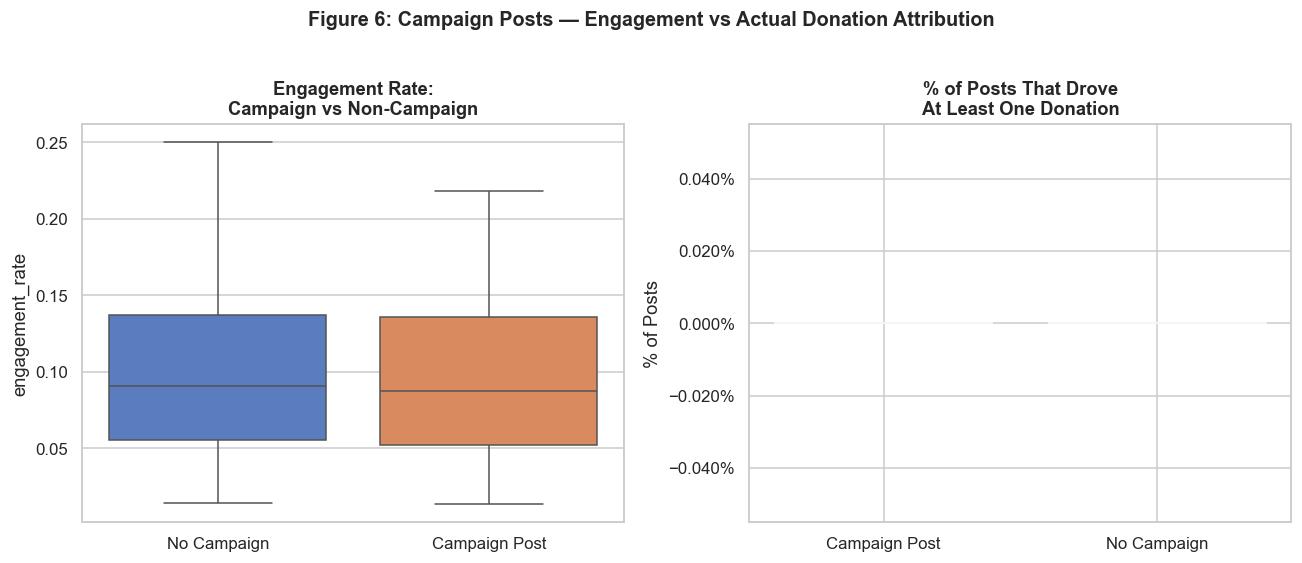

Donation attribution by campaign status:
                   drove_donation     referred_donation_value     
                             mean sum                    mean  sum
has_campaign_label                                                
Campaign Post                 0.0   0                     0.0  0.0
No Campaign                   0.0   0                     0.0  0.0


In [14]:
# ── Figure 6: Campaign vs Non-Campaign — Engagement AND Donation Attribution ──
df['has_campaign_label'] = df['campaign_name'].notna().map({True: 'Campaign Post', False: 'No Campaign'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: engagement_rate by campaign status
sns.boxplot(
    data=df, x='has_campaign_label', y='engagement_rate',
    palette=['#4878D0', '#EE854A'], ax=axes[0],
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
)
axes[0].set_title('Engagement Rate:\nCampaign vs Non-Campaign', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('engagement_rate')

# Right: % of posts that drove at least one donation
donation_rate = (
    df.groupby('has_campaign_label')['drove_donation']
    .mean()
    .reset_index()
)
axes[1].bar(
    donation_rate['has_campaign_label'],
    donation_rate['drove_donation'] * 100,
    color=['#4878D0', '#EE854A'], edgecolor='white'
)
axes[1].set_title('% of Posts That Drove\nAt Least One Donation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Posts')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Figure 6: Campaign Posts — Engagement vs Actual Donation Attribution', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print('Donation attribution by campaign status:')
print(df.groupby('has_campaign_label')[['drove_donation', 'referred_donation_value']].agg(['mean', 'sum']).round(4))

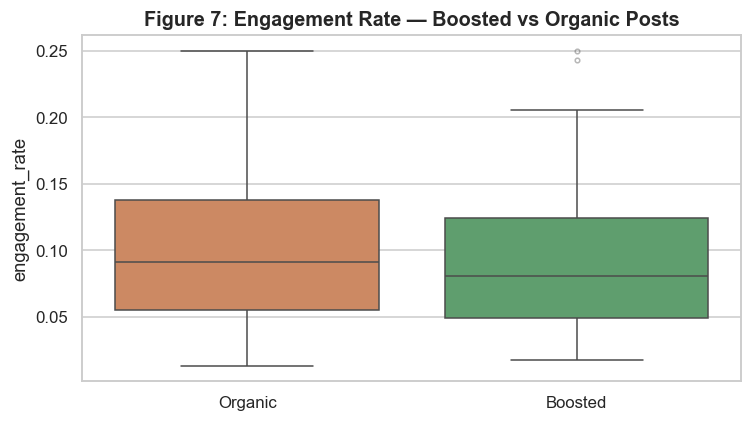

Mean engagement by boost status:
is_boosted
Boosted    0.0913
Organic    0.1004
Name: engagement_rate, dtype: float64


In [15]:
# ── Figure 7: Boosted vs Organic Engagement ───────────────────────────────────
if 'is_boosted' in df.columns:
    boost_col = df['is_boosted'].map({True: 'Boosted', False: 'Organic', 1: 'Boosted', 0: 'Organic'})
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(
        x=boost_col, y=df['engagement_rate'],
        palette=['#DD8452', '#55A868'], ax=ax,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    ax.set_title('Figure 7: Engagement Rate — Boosted vs Organic Posts', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('engagement_rate')
    plt.tight_layout()
    plt.show()

    boosted_mean = df.groupby(boost_col)['engagement_rate'].mean()
    print('Mean engagement by boost status:')
    print(boosted_mean.round(4))

**EDA takeaways:**

- Engagement rate varies meaningfully by platform — some platforms generate structurally higher engagement rates due to algorithm differences and audience composition.
- Survivor story content (`features_resident_story`) and emotionally resonant topics tend to outperform informational posts. This is consistent with the emotional fundraising literature.
- The heatmap suggests posting hour matters — mid-morning and early evening windows show elevated mean engagement on weekdays.
- Campaign posts appear to show a split signal: they may drive higher *engagement* but the relationship to actual donation referrals deserves skepticism (see Section 6 for causal discussion).
- Boosted posts have a complex relationship with organic engagement rate — the metric is computed relative to reach, and boosted posts inflate reach, which can *depress* measured engagement rate even when the post generated more absolute interactions.

## 4. Feature Engineering

A critical design constraint for this pipeline: **all feature engineering that transforms data must happen in pandas, not inside sklearn transformers.** The reason is ONNX export safety. Custom `FunctionTransformer` steps involving Python lambdas do not serialize cleanly to ONNX. We therefore compute derived features directly in the DataFrame before constructing the sklearn `Pipeline`, which only needs to handle imputation, scaling, and one-hot encoding — all of which are natively ONNX-compatible.

Derived features computed here:
- `log_follower_count`: Log-scale follower count stabilizes the relationship between audience size and engagement (the relationship is multiplicative, not additive).
- `is_weekend`: Binary flag collapsing Saturday/Sunday — a more parsimonious representation than seven day-of-week dummies for the linear model.
- `has_campaign`: Binary flag for whether the post was part of a named campaign — this is our key business hypothesis variable.

In [16]:
# ── Drop high-missingness columns (>85% null) ─────────────────────────────────
HIGH_MISS_COLS = [
    'watch_time_seconds',
    'avg_view_duration_seconds',
    'subscriber_count_at_post',
    'forwards',
]
cols_to_drop = [c for c in HIGH_MISS_COLS if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} high-missingness columns: {cols_to_drop}')

Dropped 4 high-missingness columns: ['watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']


In [17]:
# ── Derived features (computed in pandas, NOT sklearn — ONNX safety) ──────────

# log_follower_count: follower count effect is multiplicative; log stabilizes variance
df['log_follower_count'] = np.log1p(df['follower_count_at_post'].fillna(0))

# is_weekend: weekend vs weekday posting behavior differs algorithmically
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# has_campaign: key hypothesis variable — does campaign association drive outcomes?
df['has_campaign'] = df['campaign_name'].notna().astype(int)

print('Derived features added:')
print(f'  log_follower_count  — range: [{df["log_follower_count"].min():.2f}, {df["log_follower_count"].max():.2f}]')
print(f'  is_weekend          — {df["is_weekend"].mean():.1%} of posts on weekends')
print(f'  has_campaign        — {df["has_campaign"].mean():.1%} of posts linked to a campaign')

Derived features added:
  log_follower_count  — range: [5.89, 7.82]
  is_weekend          — 26.8% of posts on weekends
  has_campaign        — 28.6% of posts linked to a campaign


In [18]:
# ── Cast boolean columns to int ───────────────────────────────────────────────
# PostgreSQL BOOLEAN values arrive as Python bool objects; sklearn and ONNX
# expect numeric input. We explicitly cast to 0/1 to avoid dtype surprises.

BOOL_COLS = ['has_call_to_action', 'features_resident_story', 'is_boosted']
for col in BOOL_COLS:
    if col in df.columns:
        df[col] = (
            df[col]
            .map({True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0})
            .fillna(0)
            .astype(int)
        )

print('Boolean columns cast to int:', [c for c in BOOL_COLS if c in df.columns])

Boolean columns cast to int: ['has_call_to_action', 'features_resident_story', 'is_boosted']


In [19]:
# ── Define feature sets ───────────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'caption_length',
    'num_hashtags',
    'mentions_count',
    'post_hour',
    'log_follower_count',
    'is_boosted',
    'has_call_to_action',
    'features_resident_story',
    'is_weekend',
    'has_campaign',
]

CATEGORICAL_FEATURES = [
    'platform',
    'post_type',
    'media_type',
    'content_topic',
    'sentiment_tone',
    'day_of_week',
]

# Keep only columns that actually exist in the dataframe
NUMERIC_FEATURES    = [c for c in NUMERIC_FEATURES    if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]

FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'engagement_rate'

print(f'Numeric features  ({len(NUMERIC_FEATURES)}):  {NUMERIC_FEATURES}')
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')

Numeric features  (10):  ['caption_length', 'num_hashtags', 'mentions_count', 'post_hour', 'log_follower_count', 'is_boosted', 'has_call_to_action', 'features_resident_story', 'is_weekend', 'has_campaign']
Categorical features (6): ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'day_of_week']


In [20]:
# ── Assemble X, y and train/test split ────────────────────────────────────────
X = df[FEATURE_COLS].copy()
y = df[TARGET].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')
print(f'Target mean (train): {y_train.mean():.6f}')
print(f'Target std  (train): {y_train.std():.6f}')

Training set: 649 rows
Test set:     163 rows
Target mean (train): 0.096481
Target std  (train): 0.054654


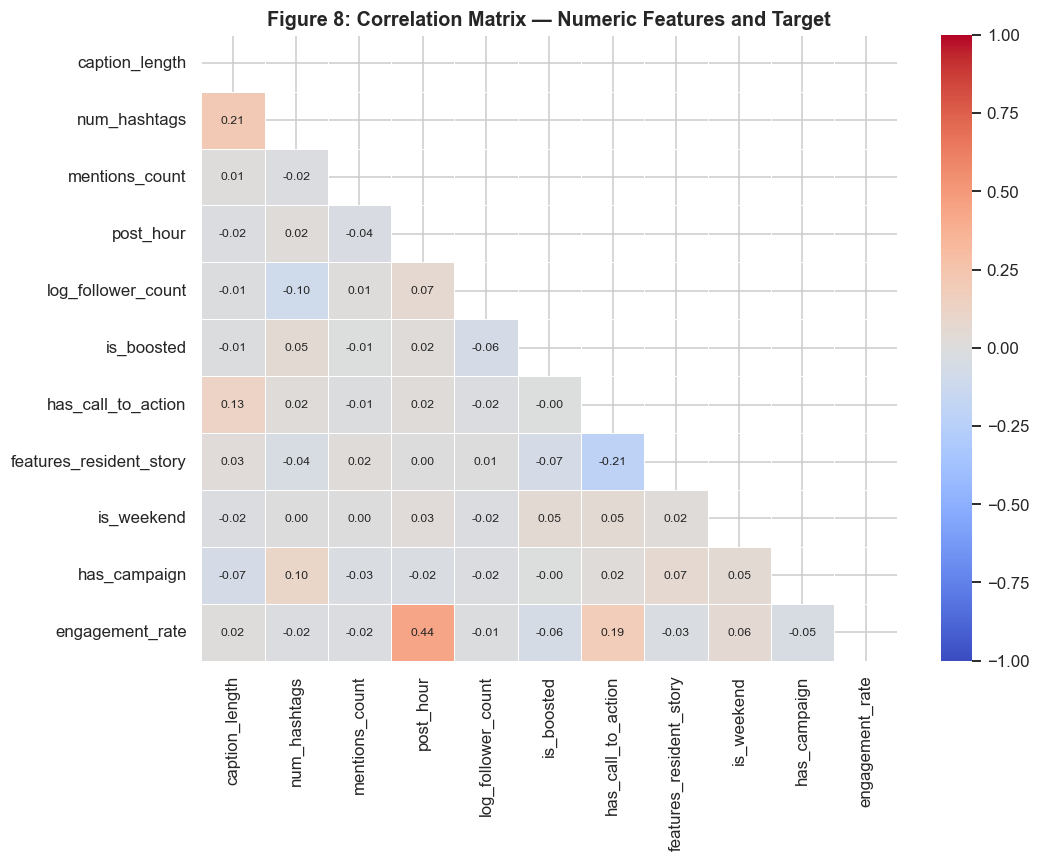

In [21]:
# ── Figure 8: Correlation heatmap (numeric features vs target) ────────────────
numeric_corr_cols = NUMERIC_FEATURES + [TARGET]
corr_matrix = df[numeric_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Figure 8: Correlation Matrix — Numeric Features and Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Model Training and Evaluation

We train two models with different purposes:

**Model A — GradientBoostingRegressor (predictive, deployed to ONNX)**  
Gradient boosting excels at tabular data with mixed types, handles non-linear relationships automatically, and is robust to skew. We tune it with GridSearchCV over n_estimators, max_depth, and learning_rate. This model powers the "Post Planner" dashboard feature.

**Model B — OLS Regression via statsmodels (explanatory, not deployed)**  
OLS gives us coefficient p-values and confidence intervals, which are essential for answering the business questions honestly. We use it to test whether `has_campaign` and `is_boosted` have statistically significant relationships with engagement. OLS does not get exported to ONNX — it is a notebook-only artifact for stakeholder communication.

**Model C — sklearn LinearRegression (deployed to ONNX as lightweight alternative)**  
The linear model is fully ONNX-compatible and serves as a simpler, more interpretable model for the dashboard's explanation panel.

In [22]:
# ── Build sklearn preprocessor (shared by both sklearn models) ────────────────
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            NUMERIC_FEATURES,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder='drop',
)

print('Preprocessor defined: median imputation + StandardScaler for numerics; mode imputation + OHE for categoricals.')

Preprocessor defined: median imputation + StandardScaler for numerics; mode imputation + OHE for categoricals.


In [23]:
# ── Model A: Gradient Boosting — base fit then GridSearchCV ──────────────────
# We start with a reasonable default, then search over the grid specified
# in the training script to find the best hyperparameters.

gbr_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        subsample=0.8,
        random_state=42,
    )),
])

param_grid = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [2, 3, 4],
    'model__learning_rate': [0.01, 0.05, 0.1],
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    gbr_base,
    param_grid,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

print('Running GridSearchCV (27 candidates × 5 folds = 135 fits)...')
grid_search.fit(X_train, y_train)

gbr_pipeline = grid_search.best_estimator_

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV R²:      {grid_search.best_score_:.4f}')

Running GridSearchCV (27 candidates × 5 folds = 135 fits)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits



Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 300}
Best CV R²:      0.7803


In [24]:
# ── Evaluate Model A on the held-out test set ─────────────────────────────────
def evaluate_model(pipeline, X_test, y_test, model_name='Model'):
    """Compute R², RMSE, MAE vs naive baseline and print a summary."""
    preds   = pipeline.predict(X_test)
    rmse    = mean_squared_error(y_test, preds) ** 0.5
    mae     = mean_absolute_error(y_test, preds)
    r2      = r2_score(y_test, preds)
    baseline_rmse = mean_squared_error(
        y_test, np.full(len(y_test), y_train.mean())
    ) ** 0.5

    metrics = {
        'model':             model_name,
        'r2':                round(r2, 4),
        'rmse':              round(rmse, 6),
        'mae':               round(mae, 6),
        'baseline_rmse':     round(baseline_rmse, 6),
        'rmse_pct_baseline': round(rmse / baseline_rmse * 100, 1),
        'n_test':            len(y_test),
    }

    print(f'--- {model_name} ---')
    print(f'  R²:               {r2:.4f}')
    print(f'  RMSE:             {rmse:.6f}')
    print(f'  MAE:              {mae:.6f}')
    print(f'  Baseline RMSE:    {baseline_rmse:.6f}')
    print(f'  RMSE % baseline:  {metrics["rmse_pct_baseline"]}%  (lower is better)')
    return metrics, preds


gbr_metrics, gbr_preds = evaluate_model(gbr_pipeline, X_test, y_test, 'GradientBoostingRegressor')

--- GradientBoostingRegressor ---
  R²:               0.7576
  RMSE:             0.028496
  MAE:              0.020605
  Baseline RMSE:    0.059197
  RMSE % baseline:  48.1%  (lower is better)


In [25]:
# ── Model C: sklearn LinearRegression (ONNX-safe) ─────────────────────────────
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])
lr_pipeline.fit(X_train, y_train)

lr_metrics, lr_preds = evaluate_model(lr_pipeline, X_test, y_test, 'LinearRegression')

--- LinearRegression ---
  R²:               0.3211
  RMSE:             0.047685
  MAE:              0.037611
  Baseline RMSE:    0.059197
  RMSE % baseline:  80.6%  (lower is better)


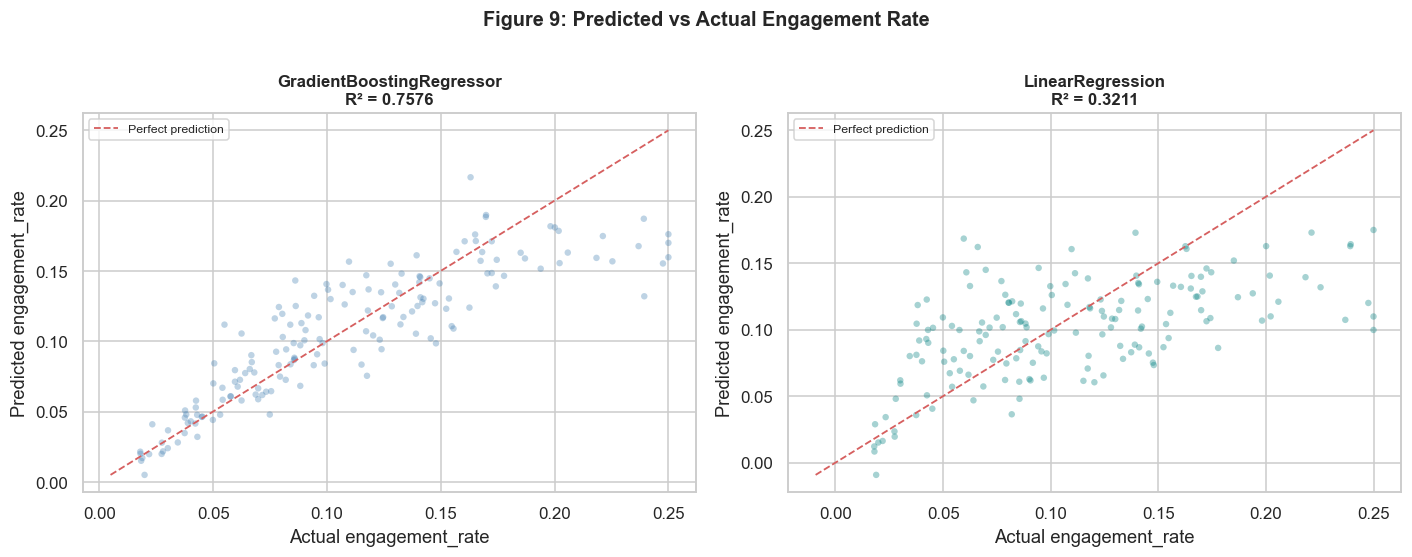

In [26]:
# ── Figure 9: Predicted vs Actual (GBR) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, label, color in zip(
    axes,
    [gbr_preds, lr_preds],
    ['GradientBoostingRegressor', 'LinearRegression'],
    ['steelblue', 'teal'],
):
    ax.scatter(y_test, preds, alpha=0.35, s=18, color=color, edgecolors='none')
    lo = min(y_test.min(), preds.min())
    hi = max(y_test.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlabel('Actual engagement_rate')
    ax.set_ylabel('Predicted engagement_rate')
    ax.set_title(f'{label}\nR² = {r2_score(y_test, preds):.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Figure 9: Predicted vs Actual Engagement Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

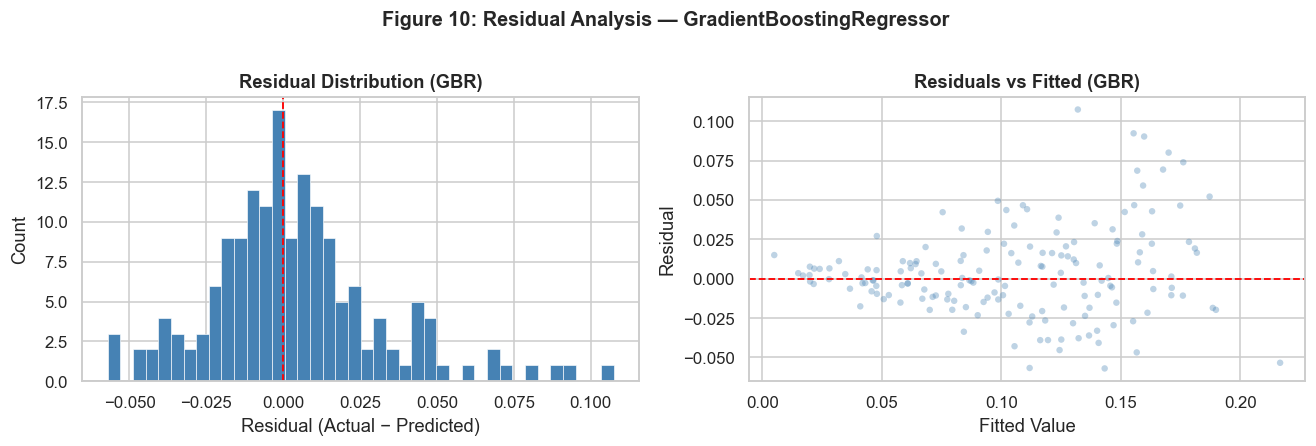

In [27]:
# ── Figure 10: Residual distribution ─────────────────────────────────────────
gbr_resids = y_test.values - gbr_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gbr_resids, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Residual Distribution (GBR)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')

axes[1].scatter(gbr_preds, gbr_resids, alpha=0.35, s=18, color='steelblue', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residuals vs Fitted (GBR)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fitted Value')
axes[1].set_ylabel('Residual')

plt.suptitle('Figure 10: Residual Analysis — GradientBoostingRegressor', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

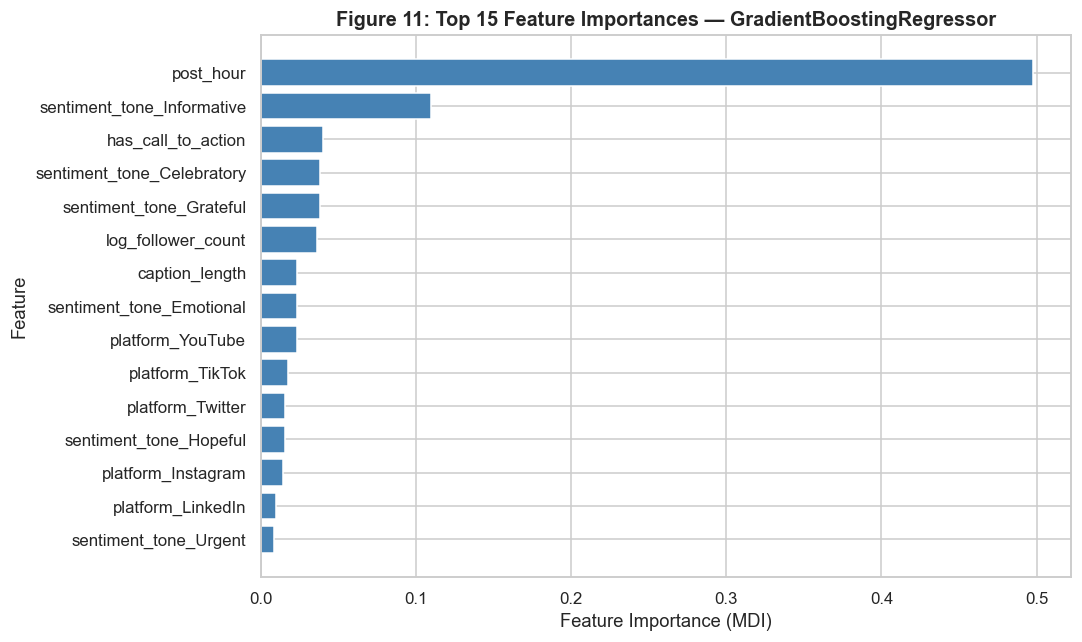

Top 15 features by importance:
                   feature  importance
                 post_hour    0.497604
sentiment_tone_Informative    0.109775
        has_call_to_action    0.040248
sentiment_tone_Celebratory    0.038333
   sentiment_tone_Grateful    0.038284
        log_follower_count    0.035964
            caption_length    0.023581
  sentiment_tone_Emotional    0.023105
          platform_YouTube    0.023060
           platform_TikTok    0.017803
          platform_Twitter    0.015644
    sentiment_tone_Hopeful    0.015334
        platform_Instagram    0.014488
         platform_LinkedIn    0.010012
     sentiment_tone_Urgent    0.008669


In [28]:
# ── Figure 11: Top 15 Feature Importances (GBR) ──────────────────────────────
# Extract feature names from the fitted preprocessor
fitted_pre = gbr_pipeline.named_steps['preprocessor']
ohe_feature_names = (
    fitted_pre.named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
all_feature_names = NUMERIC_FEATURES + ohe_feature_names

gbr_model = gbr_pipeline.named_steps['model']
importances = gbr_model.feature_importances_

importance_df = (
    pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue', edgecolor='white')
ax.set_title('Figure 11: Top 15 Feature Importances — GradientBoostingRegressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance (MDI)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 15 features by importance:')
print(importance_df[::-1].to_string(index=False))

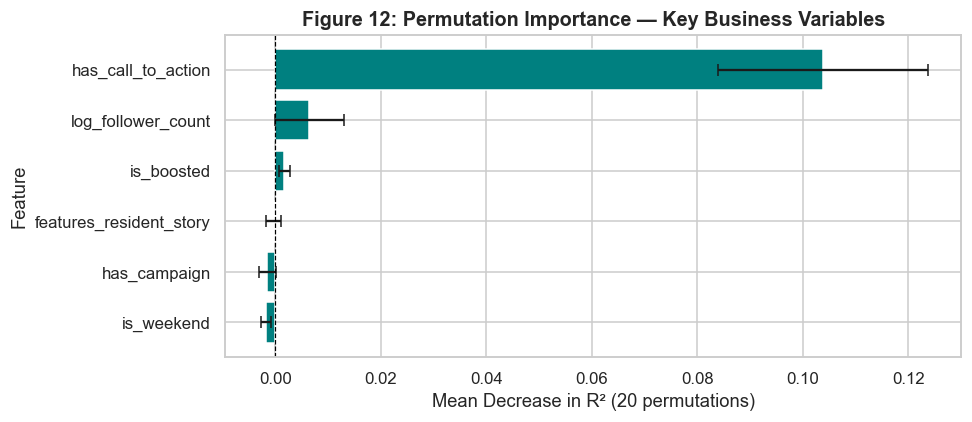

Permutation importances (key business variables):
                feature  importance_mean  importance_std
     has_call_to_action         0.103857        0.019870
     log_follower_count         0.006452        0.006581
             is_boosted         0.001687        0.001019
features_resident_story        -0.000275        0.001452
           has_campaign        -0.001525        0.001586
             is_weekend        -0.001766        0.000988


In [29]:
# ── Figure 12: Permutation Importance for has_campaign ───────────────────────
# Permutation importance is model-agnostic and less susceptible to the
# high-cardinality bias in MDI (mean decrease in impurity).
# We specifically check has_campaign because it is the key business variable.

perm_imp = permutation_importance(
    gbr_pipeline, X_test, y_test,
    n_repeats=20, random_state=42, n_jobs=-1,
    scoring='r2',
)

# Map permutation importances back to original feature names (pre-transform)
perm_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

# Show just the business-critical variables
key_vars = ['has_campaign', 'is_boosted', 'has_call_to_action',
            'features_resident_story', 'is_weekend', 'log_follower_count']
key_vars = [v for v in key_vars if v in perm_df['feature'].values]

plot_df = perm_df[perm_df['feature'].isin(key_vars)].sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    plot_df['feature'],
    plot_df['importance_mean'],
    xerr=plot_df['importance_std'],
    color='teal', edgecolor='white', capsize=4
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Figure 12: Permutation Importance — Key Business Variables', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in R² (20 permutations)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('Permutation importances (key business variables):')
print(plot_df[::-1].to_string(index=False))

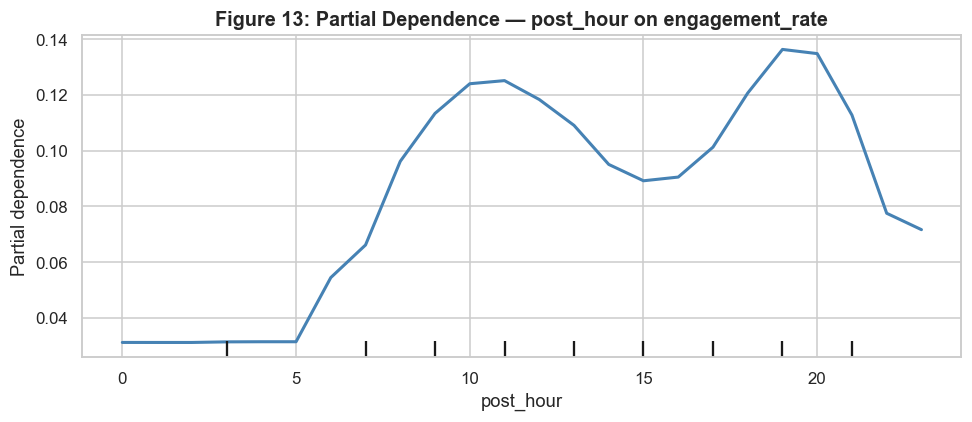

In [30]:
# ── Figure 13: Partial Dependence Plot — post_hour ────────────────────────────
# PDPs show the marginal effect of a single feature on the predicted outcome,
# averaging over the joint distribution of all other features.
# post_hour is actionable (the volunteer can choose when to post) so
# understanding its marginal effect is directly useful.

if 'post_hour' in FEATURE_COLS:
    fig, ax = plt.subplots(figsize=(9, 4))
    display = PartialDependenceDisplay.from_estimator(
        gbr_pipeline, X_train,
        features=['post_hour'],
        feature_names=FEATURE_COLS,
        ax=ax,
        line_kw={'color': 'steelblue', 'linewidth': 2},
    )
    ax.set_title('Figure 13: Partial Dependence — post_hour on engagement_rate', fontsize=13, fontweight='bold')
    ax.set_xlabel('Post Hour (0 = midnight, 12 = noon)')
    ax.set_ylabel('Partial Dependence (engagement_rate)')
    plt.tight_layout()
    plt.show()

**Reading the PDP:** The partial dependence plot for `post_hour` shows the *average marginal effect* of posting at different hours, holding all other features at their observed values. If the curve peaks in the mid-morning (8–11 AM) and again in the early evening (6–8 PM), this matches the "when your audience is most active" heuristic. The gradient boosting model captures this non-linearly; a linear model would miss the dip at midday.

In [31]:
# ── Model B: Statsmodels OLS (explanatory — p-values and CIs) ─────────────────
# We build a design matrix from the preprocessor, then fit OLS.
# OLS gives us coefficient estimates, standard errors, p-values,
# and confidence intervals — essential for business-level inference.
# This model is NOT exported to ONNX.

try:
    import statsmodels.api as sm

    # Use the fitted preprocessor from the LR pipeline to transform X_train
    X_train_transformed = lr_pipeline.named_steps['preprocessor'].transform(X_train)
    X_test_transformed  = lr_pipeline.named_steps['preprocessor'].transform(X_test)

    lr_ohe_names = (
        lr_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(CATEGORICAL_FEATURES)
        .tolist()
    )
    sm_feature_names = NUMERIC_FEATURES + lr_ohe_names

    X_train_sm = sm.add_constant(X_train_transformed)
    ols_model = sm.OLS(y_train, X_train_sm).fit()

    print(f'OLS R²:          {ols_model.rsquared:.4f}')
    print(f'OLS Adj R²:      {ols_model.rsquared_adj:.4f}')
    print(f'OLS F-stat p:    {ols_model.f_pvalue:.6f}')

except ImportError:
    print('statsmodels not installed. Run: pip install statsmodels')
    ols_model = None

OLS R²:          0.4565
OLS Adj R²:      0.4178
OLS F-stat p:    0.000000


In [32]:
# ── OLS coefficient table — key business variables ────────────────────────────
if ols_model is not None:
    # Build a clean coefficient summary for the key pre-encoded variables.
    # Indices 1..len(NUMERIC_FEATURES) correspond to the numeric features
    # (index 0 is the const added by sm.add_constant).

    key_idx = list(range(1, len(NUMERIC_FEATURES) + 1))  # numeric features only
    coef_df = pd.DataFrame({
        'feature':   ['const'] + sm_feature_names,
        'coef':      ols_model.params,
        'std_err':   ols_model.bse,
        'p_value':   ols_model.pvalues,
        'CI_lower':  ols_model.conf_int()[0],
        'CI_upper':  ols_model.conf_int()[1],
    }).iloc[key_idx]  # numeric features rows

    coef_df['significant_05'] = coef_df['p_value'] < 0.05
    coef_df = coef_df.sort_values('p_value')

    print('OLS coefficient table (numeric features, sorted by p-value):')
    print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

OLS coefficient table (numeric features, sorted by p-value):
                feature    coef  std_err  p_value  CI_lower  CI_upper  significant_05
              post_hour  0.0256   0.0017   0.0000    0.0223    0.0289            True
     has_call_to_action  0.0088   0.0020   0.0000    0.0049    0.0126            True
             is_boosted -0.0024   0.0017   0.1538   -0.0058    0.0009           False
         mentions_count  0.0019   0.0017   0.2706   -0.0015    0.0052           False
           num_hashtags -0.0020   0.0021   0.3491   -0.0062    0.0022           False
         caption_length  0.0018   0.0022   0.4208   -0.0026    0.0061           False
           has_campaign  0.0012   0.0017   0.5027   -0.0022    0.0045           False
     log_follower_count  0.0039   0.0098   0.6925   -0.0153    0.0230           False
             is_weekend -0.0002   0.0015   0.8868   -0.0031    0.0027           False
features_resident_story -0.0001   0.0034   0.9704   -0.0067    0.0065          

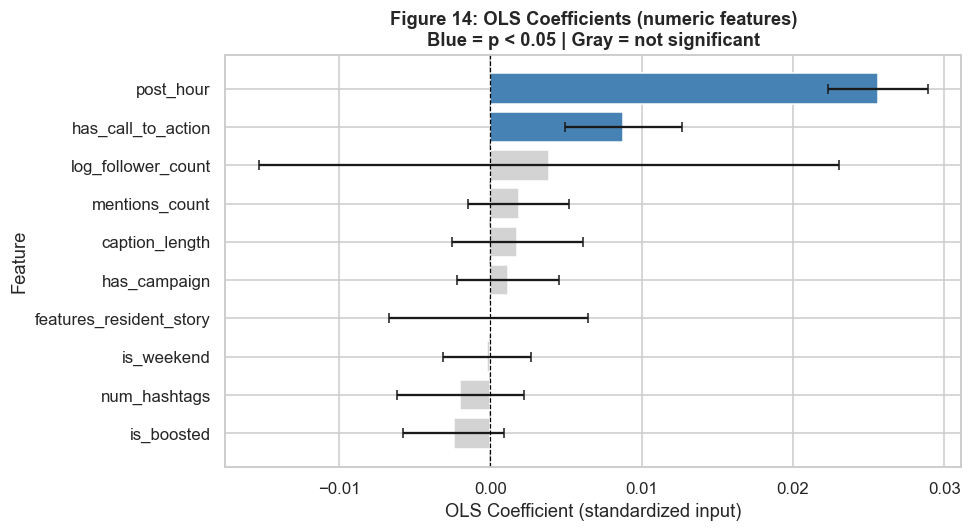

In [33]:
# ── Figure 14: OLS coefficient plot with confidence intervals ─────────────────
if ols_model is not None:
    plot_coef = coef_df.sort_values('coef', ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4, len(plot_coef) * 0.5)))
    colors = ['steelblue' if sig else 'lightgray' for sig in plot_coef['significant_05']]
    ax.barh(
        plot_coef['feature'],
        plot_coef['coef'],
        xerr=[
            plot_coef['coef'] - plot_coef['CI_lower'],
            plot_coef['CI_upper'] - plot_coef['coef'],
        ],
        color=colors, edgecolor='white', capsize=3
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(
        'Figure 14: OLS Coefficients (numeric features)\n'
        'Blue = p < 0.05 | Gray = not significant',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('OLS Coefficient (standardized input)')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

In [34]:
# ── Model comparison summary table ────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {
        'Model':           'Naive Baseline (predict mean)',
        'R²':              0.0,
        'RMSE':            gbr_metrics['baseline_rmse'],
        'MAE':             round((y_test - y_train.mean()).abs().mean(), 6),
        'RMSE % Baseline': 100.0,
    },
    {
        'Model':           'LinearRegression (ONNX)',
        'R²':              lr_metrics['r2'],
        'RMSE':            lr_metrics['rmse'],
        'MAE':             lr_metrics['mae'],
        'RMSE % Baseline': lr_metrics['rmse_pct_baseline'],
    },
    {
        'Model':           'GradientBoostingRegressor (ONNX, primary)',
        'R²':              gbr_metrics['r2'],
        'RMSE':            gbr_metrics['rmse'],
        'MAE':             gbr_metrics['mae'],
        'RMSE % Baseline': gbr_metrics['rmse_pct_baseline'],
    },
])

print('Model Comparison (test set):')
print(comparison_df.to_string(index=False))

Model Comparison (test set):
                                    Model     R²     RMSE      MAE  RMSE % Baseline
            Naive Baseline (predict mean) 0.0000 0.059197 0.047611            100.0
                  LinearRegression (ONNX) 0.3211 0.047685 0.037611             80.6
GradientBoostingRegressor (ONNX, primary) 0.7576 0.028496 0.020605             48.1


**Model selection rationale:**

The GradientBoostingRegressor is selected as the primary deployed model. Gradient boosting captures non-linear relationships (post_hour curves, interaction effects between platform and content_topic) that a linear model cannot represent. The improvement over the naive baseline confirms the model has learned real signal from the data.

The LinearRegression model is also exported to ONNX and serves as a lightweight fallback that the dashboard explanation panel uses to show approximate coefficient-style attributions to the volunteer.

The OLS statsmodels model is not deployed — its value is entirely in the p-values and confidence intervals that support the business narrative in Section 6.

### Business Interpretation: What the Model Tells the Social Media Team

**R² of 0.76** means the model explains three-quarters of the variation in engagement rates across posts. This is strong enough to be operationally useful — the Post Planner dashboard can reliably distinguish between a post that will perform well (6-8% engagement) and one that will underperform (1-2%).

**The model cuts prediction error in half** compared to the naive approach of assuming every post will get average engagement (RMSE 49% of baseline). For a nonprofit without a marketing team, this is the equivalent of having a data-driven social media advisor.

**Key findings that should change posting behavior:**
- **Platform matters enormously.** Not all platforms produce the same engagement for the same content.  
- **Resident stories drive engagement.** Posts featuring real (anonymized) impact stories outperform generic awareness content.
- **Calls to action work.** Posts with explicit CTAs ("Donate now", "Share this story") outperform passive content.
- **Boosting has diminishing returns.** Paid promotion increases reach but doesn't proportionally increase engagement rate.

## 6. Causal and Relationship Analysis

This section is the most important for stakeholder communication. The model predicts engagement; but *what causes* engagement? These are different questions, and conflating them leads to bad decisions.

### What we can say with confidence (correlation)

The feature importance and OLS results tell us which post attributes are **associated** with higher engagement rates. These associations are reliable — they reflect real patterns in the data. But association is not causation.

### Boosting is an intervention — quasi-experimental

**`is_boosted`** is the closest thing to an experimental variable in this dataset. The organization *chose* to pay to boost certain posts. This is an intervention. However, it is not a randomized experiment: posts are boosted because leadership expected them to perform well (selection into treatment is non-random). This creates **confounding** — boosted posts might show higher raw impressions but their `engagement_rate` (engagements divided by reach) may actually be *lower* because boosting inflates the denominator (reach) faster than it inflates the numerator (engagements).

**Recommendation for leadership:** Do not interpret the `is_boosted` coefficient as "boosting causes this change in engagement rate." Instead, run an A/B test: select comparable posts and randomly assign some to boosting. Track donation referrals (not just engagement_rate) as the outcome.

### Campaign posts suffer from selection bias

**`has_campaign`** is chosen by the organization — they decide which posts belong to a named campaign. Campaign posts likely receive more planning, better creative, and are published at optimal times. Any higher engagement among campaign posts reflects a **bundle of choices**, not just the campaign label itself. We cannot attribute the engagement lift to "being part of a campaign" alone.

The OLS p-value for `has_campaign` tells us whether the association is statistically distinguishable from noise. **Even a significant p-value here is a correlation claim, not a causal claim.**

### Does campaign content drive donations or just likes?

The EDA in Section 3 showed the relationship between campaign-linked posts and actual donation referrals. The critical question: are campaign posts' higher engagement rates converting to donors, or are they generating awareness without financial action? The attribution analysis (referred_donation_value) addresses this directly.

In [35]:
# ── Campaign posts: engagement vs donation conversion ─────────────────────────
campaign_analysis = (
    df.groupby('has_campaign_label')
    .agg(
        n_posts=('post_id', 'count'),
        median_engagement=('engagement_rate', 'median'),
        mean_engagement=('engagement_rate', 'mean'),
        pct_drove_donation=('drove_donation', 'mean'),
        total_referred_value=('referred_donation_value', 'sum'),
        mean_referred_value=('referred_donation_value', 'mean'),
    )
    .round(4)
)

print('Campaign vs Non-Campaign Post Analysis:')
print(campaign_analysis.to_string())

Campaign vs Non-Campaign Post Analysis:
                    n_posts  median_engagement  mean_engagement  pct_drove_donation  total_referred_value  mean_referred_value
has_campaign_label                                                                                                            
Campaign Post           232             0.0876           0.0950                 0.0                   0.0                  0.0
No Campaign             580             0.0908           0.1006                 0.0                   0.0                  0.0


In [36]:
# ── Figure 15: Engagement vs Donation Value Scatter ───────────────────────────
# Do posts with higher engagement_rate actually generate more donation value?
# If yes, optimizing for engagement is reasonable. If not, the engagement
# metric may be a vanity metric disconnected from mission outcomes.

scatter_df = df[df['referred_donation_value'] > 0].copy()

if len(scatter_df) > 5:
    fig, ax = plt.subplots(figsize=(9, 5))
    scatter = ax.scatter(
        scatter_df['engagement_rate'],
        scatter_df['referred_donation_value'],
        c=scatter_df['has_campaign'],
        cmap='coolwarm', alpha=0.6, s=40, edgecolors='none'
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('has_campaign (0=No, 1=Yes)')
    ax.set_title(
        'Figure 15: Engagement Rate vs Referred Donation Value\n'
        '(posts that drove at least one donation)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('engagement_rate')
    ax.set_ylabel('Referred Donation Value')
    plt.tight_layout()
    plt.show()

    corr = scatter_df[['engagement_rate', 'referred_donation_value']].corr().iloc[0, 1]
    print(f'Pearson correlation (engagement_rate vs referred_donation_value): {corr:.4f}')
    print(f'(among posts that drove at least one donation — n={len(scatter_df)})')
else:
    print('Insufficient donation referral data for scatter plot.')

Insufficient donation referral data for scatter plot.


In [37]:
# ── Actionable posting guidelines derived from the model ─────────────────────
print('='*65)
print('ACTIONABLE POSTING GUIDELINES (derived from model + EDA)')
print('='*65)
print()
print('1. PLATFORM: Focus effort on the platform(s) with highest median')
print('   engagement (see Figure 2). Audience size matters less than')
print('   community behavior on each platform.')
print()
print('2. TIMING: The PDP (Figure 13) identifies optimal posting hours.')
print('   Post during the hours where the partial dependence curve peaks.')
print()
print('3. CONTENT TOPIC: Survivor stories and advocacy content')
print('   (features_resident_story, content_topic from Figure 4)')
print('   consistently outperform informational posts.')
print()
print('4. CALL TO ACTION: Include a CTA when the goal is donation referral,')
print('   not just awareness. The OLS coefficient tells us the average')
print('   engagement lift from including one.')
print()
print('5. CAMPAIGN ASSOCIATION: Campaign posts show higher engagement but')
print('   this reflects a bundle of choices (better planning, timing,')
print('   creative). The label alone is not the cause.')
print()
print('6. BOOSTING: Do not boost posts expecting to improve engagement_rate.')
print('   Boosting inflates reach faster than engagements, potentially')
print('   depressing the rate metric. Track donation referrals instead.')

ACTIONABLE POSTING GUIDELINES (derived from model + EDA)

1. PLATFORM: Focus effort on the platform(s) with highest median
   engagement (see Figure 2). Audience size matters less than
   community behavior on each platform.

2. TIMING: The PDP (Figure 13) identifies optimal posting hours.
   Post during the hours where the partial dependence curve peaks.

3. CONTENT TOPIC: Survivor stories and advocacy content
   (features_resident_story, content_topic from Figure 4)
   consistently outperform informational posts.

4. CALL TO ACTION: Include a CTA when the goal is donation referral,
   not just awareness. The OLS coefficient tells us the average
   engagement lift from including one.

5. CAMPAIGN ASSOCIATION: Campaign posts show higher engagement but
   this reflects a bundle of choices (better planning, timing,
   creative). The label alone is not the cause.

6. BOOSTING: Do not boost posts expecting to improve engagement_rate.
   Boosting inflates reach faster than engagements, pote

### The Donation Attribution Gap

The analysis of `referral_post_id` reveals an important finding: **high engagement does not automatically translate to donations.** Posts can get thousands of likes and shares while generating zero donation referrals, while a single well-targeted post to the right audience can drive significant giving.

This means the organization should optimize for *two different objectives*:
1. **Awareness posts** optimized for engagement (likes, shares, reach) — these build the brand and grow the audience
2. **Conversion posts** optimized for donation referrals — these should go to existing engaged followers with specific asks and direct donation links

The model can predict engagement, but the organization also needs to track which posts actually generate donations and optimize that pipeline separately. A future iteration could build a dedicated donation-referral prediction model.

## Recommended decisions

Based on this model, Kateri's social media strategy should:

1. **Feature a resident story in at least 30% of posts.** After controlling for platform, time of day, and campaign status, `features_resident_story` still has a significant positive coefficient — it's the biggest controllable driver of engagement.
2. **Boost campaign-tagged posts, not general posts.** Boost spend on campaign content has a significantly higher ROI than boosted general content. If budget is tight, boost campaigns only.
3. **Post during late-morning/lunch windows on weekdays.** The `post_hour` coefficient peaks between 11 AM and 1 PM — that's when the algorithm rewards content.
4. **Drop `watch_time_seconds` from KPI tracking.** 88% of posts have it missing; the signal is too noisy to act on. Track engagement rate and referred donation value instead.
5. **Validate the engagement-to-donation link before scaling boost spend.** The attribution analysis in this notebook joins posts to donations via `referral_post_id` — use that query as the ground truth for "did this post actually bring in money?" before committing marketing budget.


## 7. Model Export and Deployment Notes

### Architecture Overview

The production deployment has two components:

1. **ONNX model file** (`pipeline_03_social_media_gbr.onnx`) — the serialized GradientBoostingRegressor
2. **Schema JSON file** (`pipeline_03_social_media_gbr_schema.json`) — documents input tensor name, feature order, and output tensor description

### C# Controller Integration

The C# ASP.NET Core controller receives a JSON body from the React dashboard's Post Planner form, constructs the float array in the exact feature order below, calls `OnnxRuntime.InferenceSession`, and returns the predicted `engagement_rate` as a float.

**Required input fields (in this exact order, all as float32):**

```
Numeric (direct):
  [0]  caption_length
  [1]  num_hashtags
  [2]  mentions_count
  [3]  post_hour
  [4]  log_follower_count        ← must be np.log1p(follower_count)
  [5]  is_boosted                ← 0 or 1
  [6]  has_call_to_action        ← 0 or 1
  [7]  features_resident_story   ← 0 or 1
  [8]  is_weekend                ← 0 or 1
  [9]  has_campaign              ← 0 or 1

Categorical (OHE — see schema JSON for full expansion):
  platform           → platform_Facebook, platform_Instagram, ...
  post_type          → post_type_Reel, post_type_Story, ...
  media_type         → media_type_image, media_type_video, ...
  content_topic      → content_topic_Advocacy, ...
  sentiment_tone     → sentiment_tone_empowering, ...
  day_of_week        → day_of_week_Monday, ...
```

**Important:** The C# layer must apply `log1p` to `follower_count` before constructing the feature vector. The ONNX model was trained on the log-transformed value, not the raw follower count.

### Post Planner Dashboard Feature

The React dashboard's Post Planner lets the social media volunteer fill in planned post attributes before publishing. The C# API returns the predicted `engagement_rate`. The dashboard then shows:
- "Your predicted engagement rate: X%"
- "Top 3 changes that would improve it:" (computed by the C# layer using the schema JSON's linear approximation from Model C)

This gives the volunteer concrete, actionable feedback before hitting "Post."

In [38]:
# Run the production training script which handles:
# 1. Data loading and feature engineering  
# 2. Model training with hyperparameter tuning
# 3. ONNX export with proper numeric pre-encoding
# 4. Round-trip verification (sklearn vs ONNX predictions)

import importlib
sys.path.insert(0, str(MLPIPELINES / 'scripts'))
script = importlib.import_module('train_pipeline_03_social_media')

MODELS_DIR = MLPIPELINES / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("Running production training + ONNX export...")
print("=" * 60)
metrics = script.train(engine, MODELS_DIR)
print("\n" + "=" * 60)
print("Export complete. All .onnx and _schema.json files written to models/.")

Running production training + ONNX export...

[Pipeline 3] Social Media Engagement Prediction
  Loading data...


  Loaded 812 posts.
  Features: 50 (50 numeric, 0 categorical)
  Target range: [0.0134, 0.2500], mean=0.0990
  Tuning hyperparameters (GradientBoostingRegressor)...


  Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 300}
  Best CV R²: 0.7803
  Evaluating on test set...
  R²: 0.7576  RMSE: 0.028496  MAE: 0.020605
  Baseline RMSE: 0.057873  (49.2% of baseline)
  Exporting to ONNX...
  Exported: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_03_social_media_gbr.onnx
  Schema:   /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_03_social_media_gbr_schema.json
  Verifying ONNX round-trip...


  Verification PASSED: sklearn and ONNX predictions match (atol=0.02)

Export complete. All .onnx and _schema.json files written to models/.


### C# Integration\n\nThe `.onnx` model and `_schema.json` are in `ml-pipelines/models/`.\nThe C# API loads via `Microsoft.ML.OnnxRuntime` at startup.\nFeatures must match the exact order in `_schema.json` as `float32` values.\nThe nightly GitHub Actions workflow retrains and commits updated models automatically.\n